# The PTZ mount bracket: does it survive, and does it resonate?

`dgs.ptz_helicopter_stabilization` already answers "can an active controller
keep the camera's line of sight steady against airframe vibration?" That
question assumes the physical bracket holding the gimbal to the airframe is
fine. This notebook checks the assumption: model the bracket as a cantilever
beam (fixed at the airframe, the gimbal's mass at the free tip), and ask two
separate structural questions --

1. **Strength**: does the bracket survive the gimbal's weight, scaled by a
   vibration/maneuver load factor, without exceeding material yield stress?
2. **Resonance**: does the bracket's own natural frequency stay clear of the
   helicopter's blade-pass excitation frequency (the same `BLADE_PASS_HZ`
   the stabilization module uses), or will the airframe vibration shake the
   *bracket itself* at its resonant peak?

These are genuinely separate failure modes -- a bracket can pass #1 with a
comfortable margin and still fail #2, which is exactly the second worked
example below.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import matplotlib.pyplot as plt

from dgs.ptz_mount_bracket_statics import (
    rectangular_tube_second_moment, root_bending_stress, tip_deflection,
    tip_mass_natural_frequency, check_resonance_margin, evaluate_bracket,
    RESONANCE_MARGIN_FRACTION,
)
from dgs.ptz_helicopter_stabilization import BLADE_PASS_HZ, default_gimbal_params

print(f"blade-pass excitation frequency: {BLADE_PASS_HZ:.1f} Hz")
print(f"default gimbal mass (from dgs.ptz_helicopter_stabilization): "
      f"{default_gimbal_params()['mass']} kg")

blade-pass excitation frequency: 11.0 Hz
default gimbal mass (from dgs.ptz_helicopter_stabilization): 0.5 kg


## 1 -- A well-designed bracket: strong AND clear of resonance

25mm x 15mm x 2mm-wall 6061-T6 aluminum tube, 30 cm long, carrying the
default gimbal under a 4g load factor (a representative helicopter external-
mount design load).

In [2]:
good = evaluate_bracket(length_m=0.30, outer_width_m=0.025, outer_height_m=0.015,
                        wall_thickness_m=0.002, g_load=4.0)

print(f"bracket mass: {good['bracket_mass_kg']*1000:.1f} g")
print(f"root bending stress: {good['root_bending_stress_Pa']/1e6:.1f} MPa "
      f"(factor of safety {good['factor_of_safety']:.1f})")
print(f"tip deflection: {good['tip_deflection_m']*1000:.2f} mm")
print(f"natural frequency: {good['natural_freq_hz']:.1f} Hz")
lo, hi = good['resonance_check']['keep_out_band_hz']
print(f"blade-pass keep-out band: {lo:.1f}-{hi:.1f} Hz -> "
      f"{'CLEAR' if good['resonance_check']['clears_margin'] else 'INSIDE BAND'}")
print(f"\noverall: {'ACCEPTABLE' if good['acceptable'] else 'NOT ACCEPTABLE'}")
assert good["acceptable"]

bracket mass: 116.6 g
root bending stress: 9.4 MPa (factor of safety 28.8)
tip deflection: 0.54 mm
natural frequency: 42.7 Hz
blade-pass keep-out band: 8.8-13.2 Hz -> CLEAR

overall: ACCEPTABLE


## 2 -- Strength is not sufficient: a thin-wall bracket that resonates

Same geometry, wall thickness cut to 0.1mm. The bending stress margin is
*still comfortably positive* (the bracket "would hold"), but the reduced
stiffness drops the natural frequency right into the blade-pass keep-out
band -- a failure mode strength calculations alone never catch.

In [3]:
thin = evaluate_bracket(length_m=0.30, outer_width_m=0.025, outer_height_m=0.015,
                        wall_thickness_m=0.0001, g_load=4.0)

print(f"root bending stress: {thin['root_bending_stress_Pa']/1e6:.1f} MPa "
      f"(factor of safety {thin['factor_of_safety']:.1f} -- looks fine by stress alone)")
print(f"natural frequency: {thin['natural_freq_hz']:.1f} Hz "
      f"({'CLEAR' if thin['resonance_check']['clears_margin'] else 'INSIDE BLADE-PASS KEEP-OUT BAND'})")
print(f"\noverall: {'ACCEPTABLE' if thin['acceptable'] else 'NOT ACCEPTABLE'}")
assert thin["factor_of_safety"] > 1.0
assert not thin["acceptable"]

root bending stress: 133.1 MPa (factor of safety 2.0 -- looks fine by stress alone)
natural frequency: 11.3 Hz (INSIDE BLADE-PASS KEEP-OUT BAND)

overall: NOT ACCEPTABLE


## 3 -- Sweep wall thickness: two independent pass/fail curves

Bending-stress factor of safety and natural frequency don't move together --
plotting both against wall thickness shows the resonance band as a real
"forbidden zone" a designer has to route the design around, separate from
the strength margin.

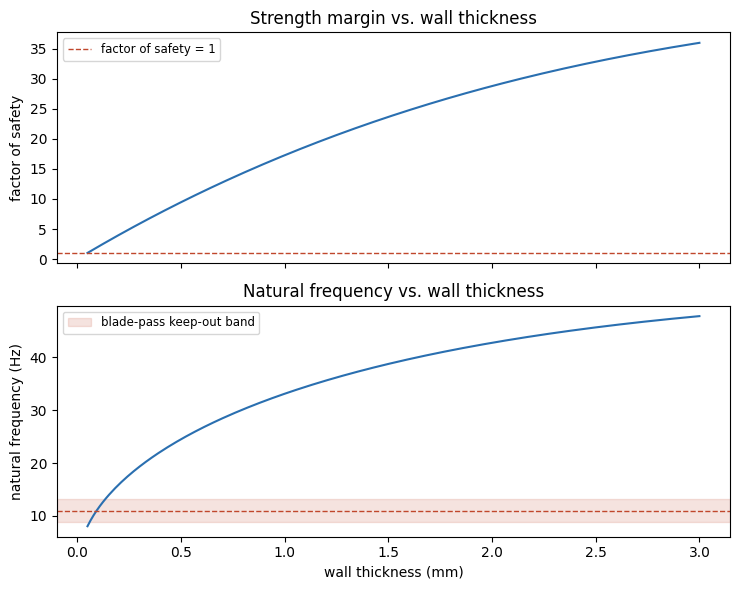

In [4]:
thicknesses_mm = np.linspace(0.05, 3.0, 200)
fos, f_n = [], []
for t_mm in thicknesses_mm:
    r = evaluate_bracket(length_m=0.30, outer_width_m=0.025, outer_height_m=0.015,
                         wall_thickness_m=t_mm/1000, g_load=4.0)
    fos.append(r["factor_of_safety"])
    f_n.append(r["natural_freq_hz"])
fos, f_n = np.array(fos), np.array(f_n)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.5, 6), sharex=True)

ax1.plot(thicknesses_mm, fos, color="#2a6fb0")
ax1.axhline(1.0, color="#c0472c", ls="--", lw=1, label="factor of safety = 1")
ax1.set_ylabel("factor of safety")
ax1.legend(fontsize=8.5)
ax1.set_title("Strength margin vs. wall thickness")

ax2.plot(thicknesses_mm, f_n, color="#2a6fb0")
lo, hi = BLADE_PASS_HZ * (1 - RESONANCE_MARGIN_FRACTION), BLADE_PASS_HZ * (1 + RESONANCE_MARGIN_FRACTION)
ax2.axhspan(lo, hi, color="#c0472c", alpha=0.15, label="blade-pass keep-out band")
ax2.axhline(BLADE_PASS_HZ, color="#c0472c", ls="--", lw=1)
ax2.set_ylabel("natural frequency (Hz)")
ax2.set_xlabel("wall thickness (mm)")
ax2.legend(fontsize=8.5)
ax2.set_title("Natural frequency vs. wall thickness")

fig.tight_layout()
plt.show()

## Summary

| Check | What it catches | Comes from |
|---|---|---|
| Bending stress / factor of safety | Bracket breaks under weight + vibration load | `root_bending_stress`, Euler-Bernoulli flexure |
| Tip deflection | Excessive sag (affects boresight alignment) | `tip_deflection`, cantilever formula |
| Natural frequency vs. blade-pass | Structural resonance amplifying vibration | `tip_mass_natural_frequency` + `check_resonance_margin` |

None of these three questions are answered by
`dgs.ptz_helicopter_stabilization`'s active-control simulation -- that module
assumes a rigid, already-adequate bracket and asks whether a *controller*
can hold the line of sight steady. This notebook is the structural
prerequisite that assumption is standing on.